# ESTIMACIÓN DEL FLUJO VEHICULAR EN PEAJES DEL PERÚ
Regresión Supervisada — PUCP · 1INF24
Blas A.

**INSTRUCCIONES PARA GOOGLE COLAB:**
1. Sube el archivo Excel del dataset a Colab:
   - Menú lateral izquierdo → ícono de carpeta → "Subir archivo"
   - Sube: `Flujo_vehicular_registrado_en_peajes_2014-2025_II.xlsx`
2. Ejecuta todas las celdas en orden (Ctrl+F9 o "Ejecutar todo")

## Instalación e importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


##  Carga del dataset

In [ ]:
# Si el archivo tiene otro nombre, cambia la ruta aquí:
RUTA = "/content/Flujo_vehicular_registrado_en_peajes_2014-2025_II.xlsx"

df_raw = pd.read_excel(RUTA)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{list(df_raw.columns)}")
print(df_raw.head(3).to_string())  # En Colab esto se ve como tabla interactiva

Dataset cargado: 10,781 filas × 23 columnas

Columnas disponibles:
['ID', 'ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'NOMBRE_PEAJE', 'VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO', 'MES', 'PERIODO']
   ID      ADMINIST CODIGO_PEAJE DEPARTAMENTO  NOMBRE_PEAJE  VEH_LIGEROS_TAR_DIF  VEH_LIGEROS_AUTOMOVILES  VEH_PESADOS_TAR_DIF  VEH_PESADOS__2E  VEH_PESADOS_3E  VEH_PESADOS_4E  VEH_PESADOS_5E  VEH_PESADOS_6E  VEH_PESADOS_7E  VEH_LIGEROS_TOTAL      VEH_LIGEROS_IMD  VEH_PESADOS_TOTAL VEH_PESADOS_IMD  VEH_TOTAL VEH_IMD  ANIO  MES  PERIODO
0   0  Concesionado   22PE5NACS1   San Martín  Aguas Claras                 2099                   8070.0                    0           2586.0          2374.0           720.0           315.0          3512.0         

##  Eliminaciòn de Nulos


In [ ]:
#df_raw.isnull().sum()*100	/df.shape[0]
df = df_raw.copy()

print(df.isnull().sum())
print((df.isnull().sum() * 100 / df.shape[0]).sort_values(ascending=False))

ID                          0
ADMINIST                    0
CODIGO_PEAJE                0
DEPARTAMENTO                0
NOMBRE_PEAJE                0
VEH_LIGEROS_TAR_DIF         0
VEH_LIGEROS_AUTOMOVILES    13
VEH_PESADOS_TAR_DIF         0
VEH_PESADOS__2E             8
VEH_PESADOS_3E              8
VEH_PESADOS_4E              8
VEH_PESADOS_5E              8
VEH_PESADOS_6E              8
VEH_PESADOS_7E              8
VEH_LIGEROS_TOTAL           0
VEH_LIGEROS_IMD             0
VEH_PESADOS_TOTAL           0
VEH_PESADOS_IMD             0
VEH_TOTAL                   0
VEH_IMD                     0
ANIO                        0
MES                         0
PERIODO                     0
dtype: int64
VEH_LIGEROS_AUTOMOVILES    0.120583
VEH_PESADOS_6E             0.074205
VEH_PESADOS_7E             0.074205
VEH_PESADOS_5E             0.074205
VEH_PESADOS_4E             0.074205
VEH_PESADOS_3E             0.074205
VEH_PESADOS__2E            0.074205
VEH_LIGEROS_TAR_DIF        0.000000
NOMBRE_PE

In [ ]:
n_antes = len(df)
df = df.dropna()
n_despues = len(df)

print(f" Filas eliminadas por valores nulos: {n_antes - n_despues:,}")
print(f" Filas tras limpieza de nulos: {n_despues:,}")

 Filas eliminadas por valores nulos: 13
 Filas tras limpieza de nulos: 10,768


## Limpieza — Paso 1: Reparar VEH_IMD
El dataset tiene un problema conocido: Excel convirtió algunos
valores decimales de VEH_IMD en fechas (ej. "1592.7" → datetime).
Los convertimos a numérico y descartamos los que quedaron nulos.

In [ ]:
df = df_raw.copy()

# Columna objetivo: VEH_IMD (Índice Medio Diario total)
df['VEH_IMD'] = pd.to_numeric(df['VEH_IMD'], errors='coerce')

nulos_imd = df['VEH_IMD'].isna().sum()
print(f" Filas con VEH_IMD no convertible (fechas corruptas): {nulos_imd:,}")
df = df.dropna(subset=['VEH_IMD'])
print(f"Filas tras eliminar nulos en VEH_IMD: {len(df):,}")

 Filas con VEH_IMD no convertible (fechas corruptas): 3,274
Filas tras eliminar nulos en VEH_IMD: 7,507


## Limpieza — Paso 2: Eliminar outliers con IQR
Los peajes con eventos atípicos (desvíos de obra, feriados
extraordinarios) generan picos que sesgan los modelos de regresión.
Aplicamos filtro IQR estándar: eliminamos valores > Q3 + 1.5*IQR

Q1=568.2 | Q3=1470.0 | IQR=901.8
   Límite superior (Q3 + 1.5×IQR) = 2822.6
Outliers eliminados: 700 filas
Dataset final para modelado: 6,807 filas


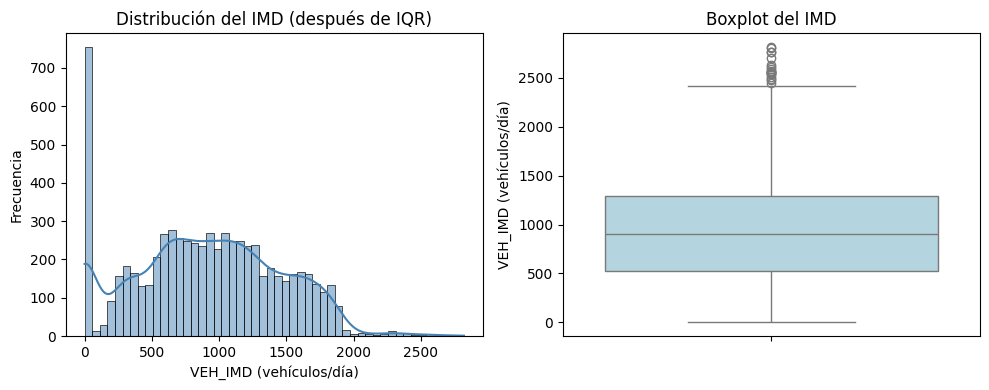

Figura guardada: fig0_distribucion_imd.png


In [ ]:
Q1 = df['VEH_IMD'].quantile(0.25)
Q3 = df['VEH_IMD'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

n_antes = len(df)
df = df[df['VEH_IMD'] <= limite_superior]
n_despues = len(df)

print(f"Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR:.1f}")
print(f"   Límite superior (Q3 + 1.5×IQR) = {limite_superior:.1f}")
print(f"Outliers eliminados: {n_antes - n_despues:,} filas")
print(f"Dataset final para modelado: {n_despues:,} filas")

# Distribución de la variable objetivo
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['VEH_IMD'], bins=50, color='steelblue', kde=True)
plt.title('Distribución del IMD (después de IQR)')
plt.xlabel('VEH_IMD (vehículos/día)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['VEH_IMD'], color='lightblue')
plt.title('Boxplot del IMD')
plt.ylabel('VEH_IMD (vehículos/día)')

plt.tight_layout()
plt.savefig('fig0_distribucion_imd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig0_distribucion_imd.png")

##  Ingeniería de variables
Variables de entrada (features) seleccionadas:
   - ANIO      : año del registro (tendencia temporal)
   - MES       : mes del registro (estacionalidad)
   - ADMINIST  : tipo de administración (Concesionado / No concesionado)
   - DEPARTAMENTO: ubicación geográfica
   - NOMBRE_PEAJE: identificador del peaje

Las variables categóricas se codifican con One-Hot Encoding para
que el modelo pueda asignar coeficientes independientes a cada
categoría sin asumir orden entre ellas.

In [ ]:
FEATURES_CAT  = ['ADMINIST', 'DEPARTAMENTO', 'NOMBRE_PEAJE']
FEATURES_NUM  = ['ANIO', 'MES']
TARGET        = 'VEH_IMD'

# One-Hot Encoding de variables categóricas
df_encoded = pd.get_dummies(df[FEATURES_NUM + FEATURES_CAT + [TARGET]],
                             columns=FEATURES_CAT,
                             drop_first=True)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f"   Variables de entrada: {X.shape[1]} columnas")
print(f"   ({len(FEATURES_NUM)} numéricas + {X.shape[1]-len(FEATURES_NUM)} dummies)")
print(f"   Variable objetivo: {TARGET}")
print(f"   Rango IMD: {y.min():.1f} – {y.max():.1f} veh/día")

   Variables de entrada: 101 columnas
   (2 numéricas + 99 dummies)
   Variable objetivo: VEH_IMD
   Rango IMD: 0.0 – 2820.0 veh/día


## División train/test + escalado
Estrategia de validación: Hold-Out 80/20 con semilla fija (42)
para reproducibilidad. Se usará también K-Fold CV (k=5).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Escalado: StandardScaler (media=0, std=1)
# Necesario para KNN (basado en distancias euclidanas).
# Se ajusta SOLO sobre train para evitar data leakage.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"   Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"   Split: 80% train / 20% test — random_state=42")

   Train: 5,445 filas | Test: 1,362 filas
   Split: 80% train / 20% test — random_state=42


##  Función auxiliar de métricas

In [ ]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te,
                   escalado=False, X_orig=None, y_orig=None):
    """
    Entrena el modelo y calcula:
      - R²   : coeficiente de determinación (qué % de varianza explica)
      - RMSE : error cuadrático medio (misma unidad que IMD: veh/día)
      - MAE  : error absoluto medio (veh/día)
    También hace K-Fold Cross-Validation (k=5) sobre train.
    """
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)

    # Cross-Validation en train (k=5)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(modelo, X_tr, y_tr, cv=kf, scoring='r2')

    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  R²   (test)  = {r2:.4f}")
    print(f"  RMSE (test)  = {rmse:.2f} veh/día")
    print(f"  MAE  (test)  = {mae:.2f} veh/día")
    print(f"  R²   (CV-5)  = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    return {
        'Modelo': nombre,
        'R² Test': round(r2, 4),
        'RMSE Test': round(rmse, 2),
        'MAE Test': round(mae, 2),
        'R² CV-5 (media)': round(cv_r2.mean(), 4),
        'R² CV-5 (std)': round(cv_r2.std(), 4),
        'y_pred': y_pred
    }

##  MODELO 1 — Regresión Lineal Múltiple
Modelo paramétrico base. Asume relación lineal entre las
variables espaciotemporales y la IMD.
Usamos los datos escalados (aunque lineal no lo requiere
estrictamente, mantiene consistencia en la comparación).


  Regresión Lineal Múltiple
  R²   (test)  = 0.3029
  RMSE (test)  = 458.79 veh/día
  MAE  (test)  = 330.57 veh/día
  R²   (CV-5)  = 0.3671 ± 0.0399


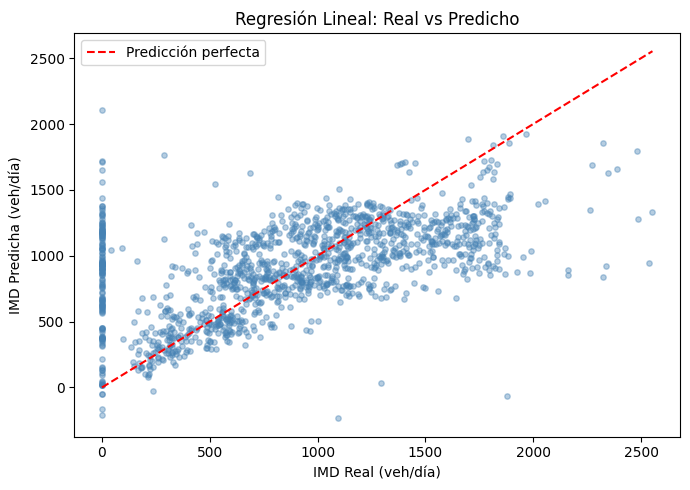

 Figura guardada: fig1_regresion_lineal.png


In [ ]:
lr_model  = LinearRegression()
res_lr    = evaluar_modelo("Regresión Lineal Múltiple", lr_model,
                            X_train_sc, y_train, X_test_sc, y_test)

# Gráfico: Real vs Predicho
plt.figure(figsize=(7, 5))
plt.scatter(y_test, res_lr['y_pred'], alpha=0.4, color='steelblue', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
plt.xlabel('IMD Real (veh/día)')
plt.ylabel('IMD Predicha (veh/día)')
plt.title('Regresión Lineal: Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.savefig('fig1_regresion_lineal.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig1_regresion_lineal.png")

##  MODELO 2 — KNN Regressor
Enfoque no paramétrico. Para elegir el mejor K, probamos
valores de 1 a 20 y graficamos R² vs K.

 Buscando mejor K para KNN...
 Mejor K = 2 (R² CV = 0.6891)


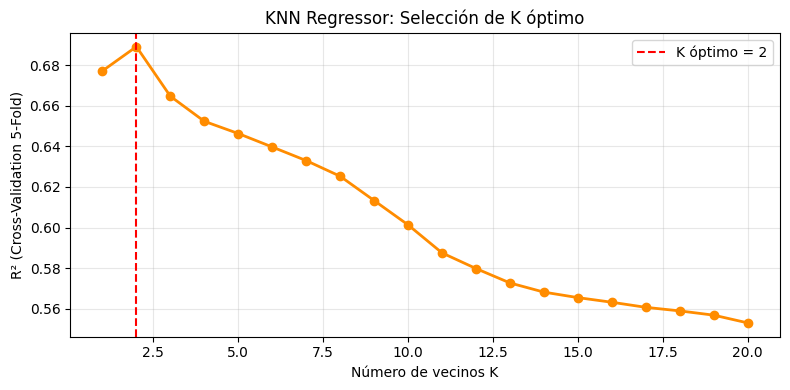

 Figura guardada: fig2a_knn_seleccion_k.png

  KNN Regressor (K óptimo)
  R²   (test)  = 0.7239
  RMSE (test)  = 288.73 veh/día
  MAE  (test)  = 142.24 veh/día
  R²   (CV-5)  = 0.6941 ± 0.0298


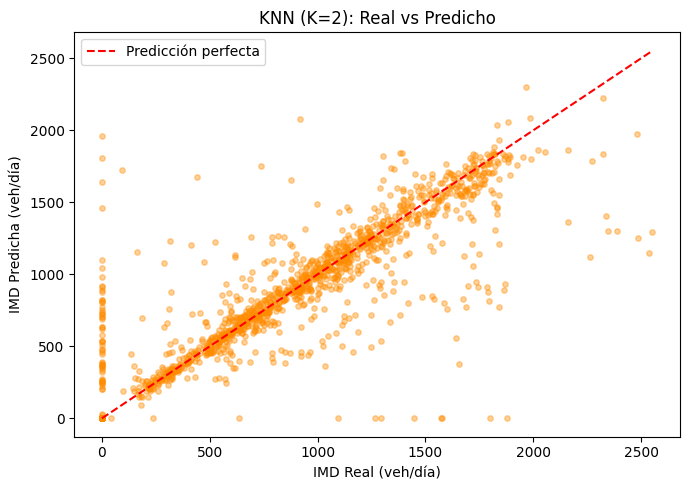

 Figura guardada: fig2b_knn_real_vs_pred.png


In [ ]:
print(" Buscando mejor K para KNN...")
k_values = range(1, 21)
r2_scores_k = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    cv = cross_val_score(knn, X_train_sc, y_train,
                         cv=5, scoring='r2')
    r2_scores_k.append(cv.mean())

mejor_k = k_values[np.argmax(r2_scores_k)]
print(f" Mejor K = {mejor_k} (R² CV = {max(r2_scores_k):.4f})")

# Gráfico K vs R²
plt.figure(figsize=(8, 4))
plt.plot(k_values, r2_scores_k, 'o-', color='darkorange', lw=2)
plt.axvline(mejor_k, color='red', linestyle='--', label=f'K óptimo = {mejor_k}')
plt.xlabel('Número de vecinos K')
plt.ylabel('R² (Cross-Validation 5-Fold)')
plt.title('KNN Regressor: Selección de K óptimo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2a_knn_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig2a_knn_seleccion_k.png")

# Entrenar KNN con K óptimo
knn_model = KNeighborsRegressor(n_neighbors=mejor_k)
res_knn   = evaluar_modelo("KNN Regressor (K óptimo)", knn_model,
                            X_train_sc, y_train, X_test_sc, y_test)

# Gráfico: Real vs Predicho
plt.figure(figsize=(7, 5))
plt.scatter(y_test, res_knn['y_pred'], alpha=0.4, color='darkorange', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
plt.xlabel('IMD Real (veh/día)')
plt.ylabel('IMD Predicha (veh/día)')
plt.title(f'KNN (K={mejor_k}): Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.savefig('fig2b_knn_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig2b_knn_real_vs_pred.png")

##  MODELO 3 — Árbol de Regresión
Modelo jerárquico que particiona el espacio de entrada mediante
reglas condicionales. Se limita la profundidad (max_depth) para
evitar sobreajuste y se usa CV para elegirla.

 Buscando profundidad óptima para el Árbol...
 Profundidad óptima = 20 (R² CV = 0.7308)


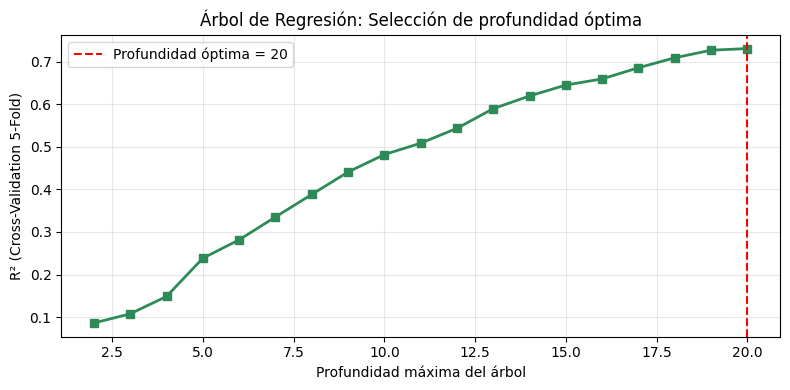

 Figura guardada: fig3a_arbol_seleccion_depth.png

  Árbol de Regresión (profundidad óptima)
  R²   (test)  = 0.7603
  RMSE (test)  = 269.05 veh/día
  MAE  (test)  = 140.66 veh/día
  R²   (CV-5)  = 0.7245 ± 0.0148


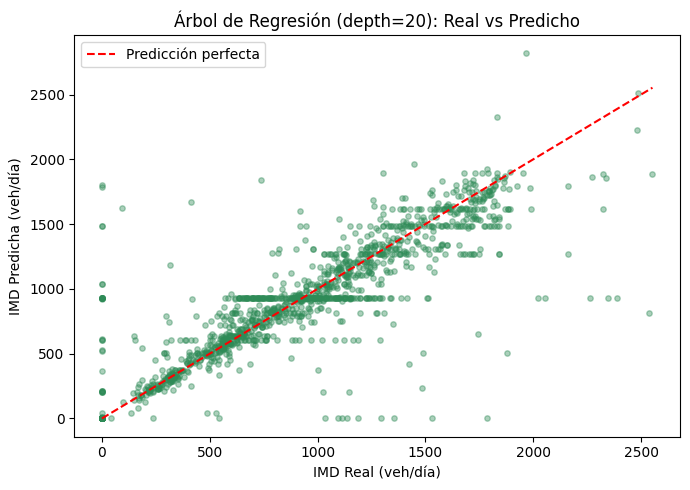

 Figura guardada: fig3b_arbol_real_vs_pred.png


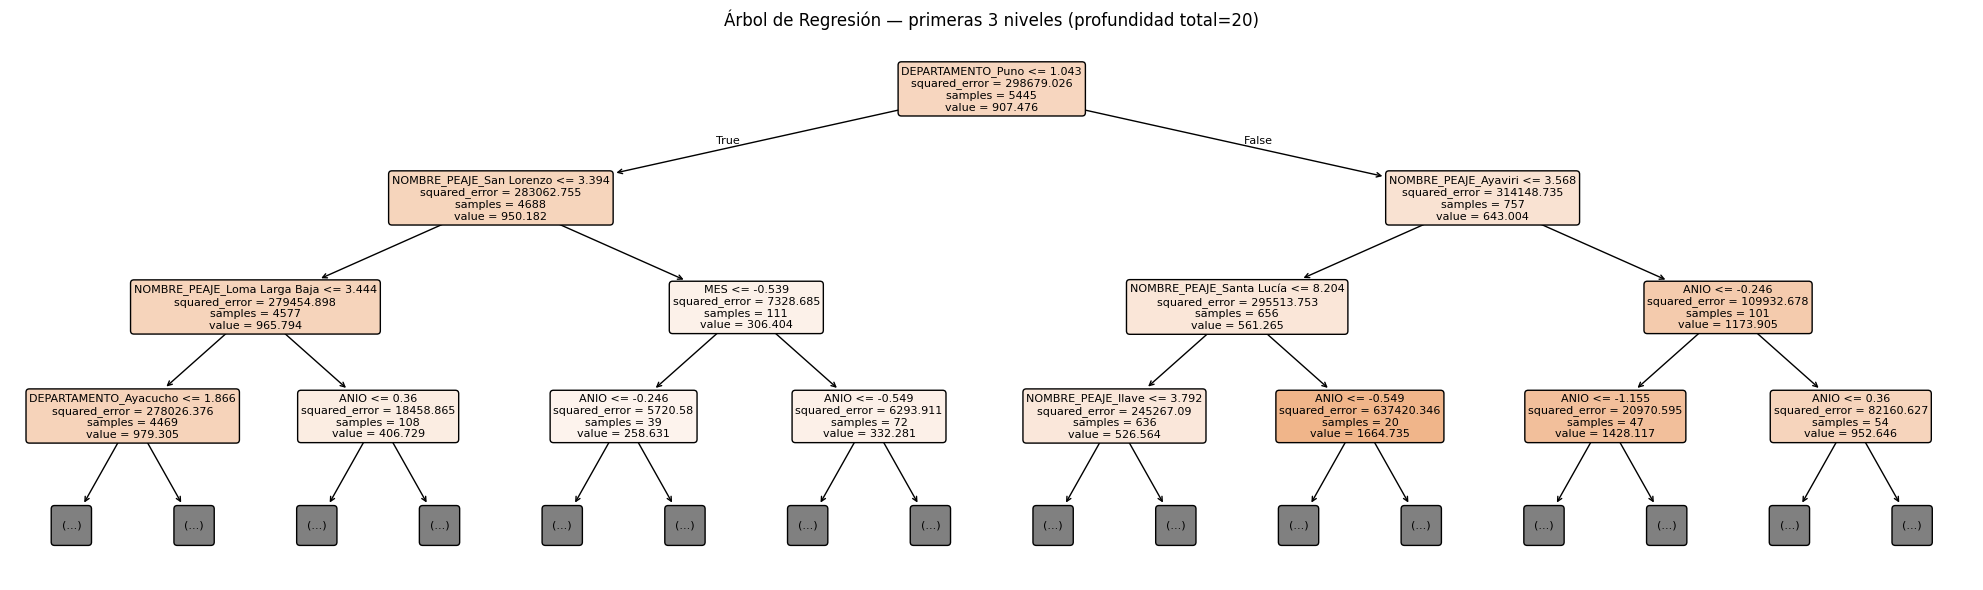

 Figura guardada: fig3c_arbol_visualizacion.png


In [ ]:
print(" Buscando profundidad óptima para el Árbol...")
depths = range(2, 21)
r2_scores_d = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    cv = cross_val_score(tree, X_train_sc, y_train,
                         cv=5, scoring='r2')
    r2_scores_d.append(cv.mean())

mejor_depth = depths[np.argmax(r2_scores_d)]
print(f" Profundidad óptima = {mejor_depth} (R² CV = {max(r2_scores_d):.4f})")

# Gráfico profundidad vs R²
plt.figure(figsize=(8, 4))
plt.plot(depths, r2_scores_d, 's-', color='seagreen', lw=2)
plt.axvline(mejor_depth, color='red', linestyle='--',
            label=f'Profundidad óptima = {mejor_depth}')
plt.xlabel('Profundidad máxima del árbol')
plt.ylabel('R² (Cross-Validation 5-Fold)')
plt.title('Árbol de Regresión: Selección de profundidad óptima')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3a_arbol_seleccion_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig3a_arbol_seleccion_depth.png")

# Entrenar árbol con profundidad óptima
tree_model = DecisionTreeRegressor(max_depth=mejor_depth, random_state=42)
res_tree   = evaluar_modelo("Árbol de Regresión (profundidad óptima)",
                             tree_model, X_train_sc, y_train,
                             X_test_sc, y_test)

# Gráfico: Real vs Predicho
plt.figure(figsize=(7, 5))
plt.scatter(y_test, res_tree['y_pred'], alpha=0.4, color='seagreen', s=15)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5, label='Predicción perfecta')
plt.xlabel('IMD Real (veh/día)')
plt.ylabel('IMD Predicha (veh/día)')
plt.title(f'Árbol de Regresión (depth={mejor_depth}): Real vs Predicho')
plt.legend()
plt.tight_layout()
plt.savefig('fig3b_arbol_real_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig3b_arbol_real_vs_pred.png")

# Visualización del árbol (primeras 3 ramas para legibilidad)
cols_display = X.columns.tolist()
plt.figure(figsize=(20, 6))
plot_tree(tree_model, max_depth=3, feature_names=cols_display,
          filled=True, rounded=True, fontsize=8)
plt.title(f'Árbol de Regresión — primeras 3 niveles (profundidad total={mejor_depth})')
plt.tight_layout()
plt.savefig('fig3c_arbol_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig3c_arbol_visualizacion.png")

## Tabla comparativa de resultados


  TABLA COMPARATIVA DE MODELOS
                                         R² Test  RMSE Test  MAE Test  R² CV-5 (media)  R² CV-5 (std)
Modelo                                                                                               
Regresión Lineal Múltiple                 0.3029     458.79    330.57           0.3671         0.0399
KNN Regressor (K óptimo)                  0.7239     288.73    142.24           0.6941         0.0298
Árbol de Regresión (profundidad óptima)   0.7603     269.05    140.66           0.7245         0.0148


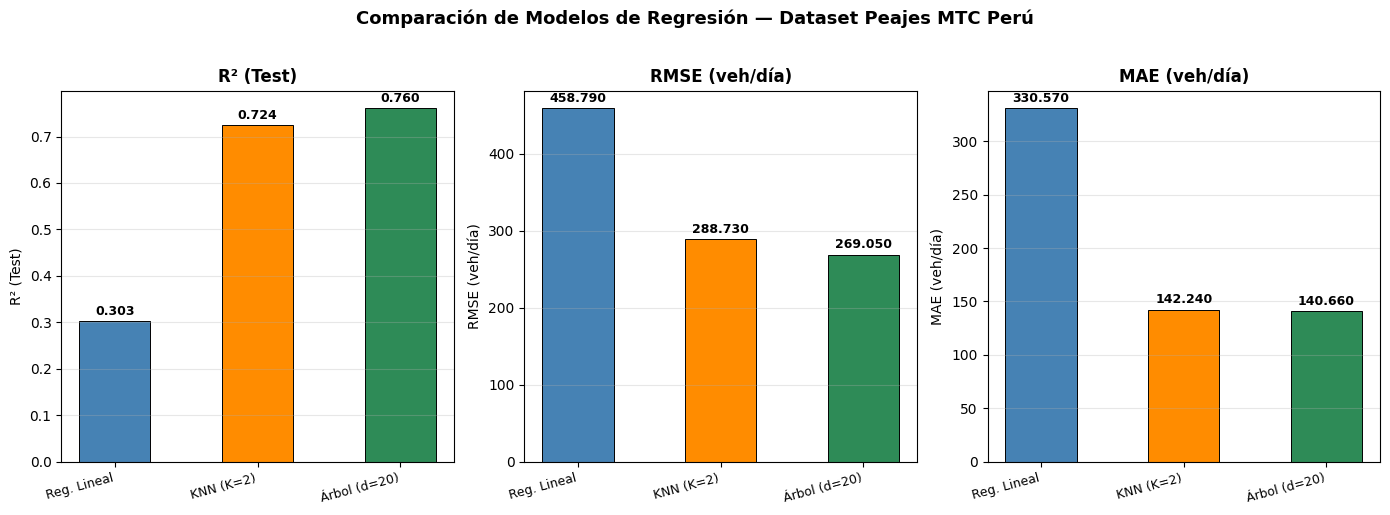

 Figura guardada: fig4_comparacion_modelos.png


In [ ]:
resultados = pd.DataFrame([
    {k: v for k, v in res_lr.items()   if k != 'y_pred'},
    {k: v for k, v in res_knn.items()  if k != 'y_pred'},
    {k: v for k, v in res_tree.items() if k != 'y_pred'},
])
resultados = resultados.set_index('Modelo')

print("\n" + "="*70)
print("  TABLA COMPARATIVA DE MODELOS")
print("="*70)
print(resultados.to_string())

# Gráfico de barras comparativo — R²
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
modelos   = resultados.index.tolist()
colores   = ['steelblue', 'darkorange', 'seagreen']

metricas_plot = {
    'R² Test': 'R² (Test)',
    'RMSE Test': 'RMSE (veh/día)',
    'MAE Test':  'MAE (veh/día)'
}

for ax, (col, titulo) in zip(axes, metricas_plot.items()):
    vals = resultados[col].values
    bars = ax.bar(modelos, vals, color=colores, width=0.5, edgecolor='black', lw=0.7)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel(titulo)
    ax.set_xticklabels(['Reg. Lineal', f'KNN (K={mejor_k})', f'Árbol (d={mejor_depth})'],
                        rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Modelos de Regresión — Dataset Peajes MTC Perú',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig4_comparacion_modelos.png")

##  Análisis de residuos

**EXPLICACION**: Imagina que el modelo predice que en el peaje X van a pasar 800 vehículos/día, pero en realidad pasaron 950.
El residuo sería: 950 - 800 = +150 (se quedó corto)
Si hubiera predicho 1,050, el residuo sería: 950 - 1,050 = -100 (se pasó)

El gráfico muestra eso para TODOS los registros del test a la vez:

Eje X → lo que predijo el modelo


Eje Y → cuánto se equivocó (arriba = se quedó corto, abajo = se pasó)
Línea roja → error = 0, o sea predicción perfecta

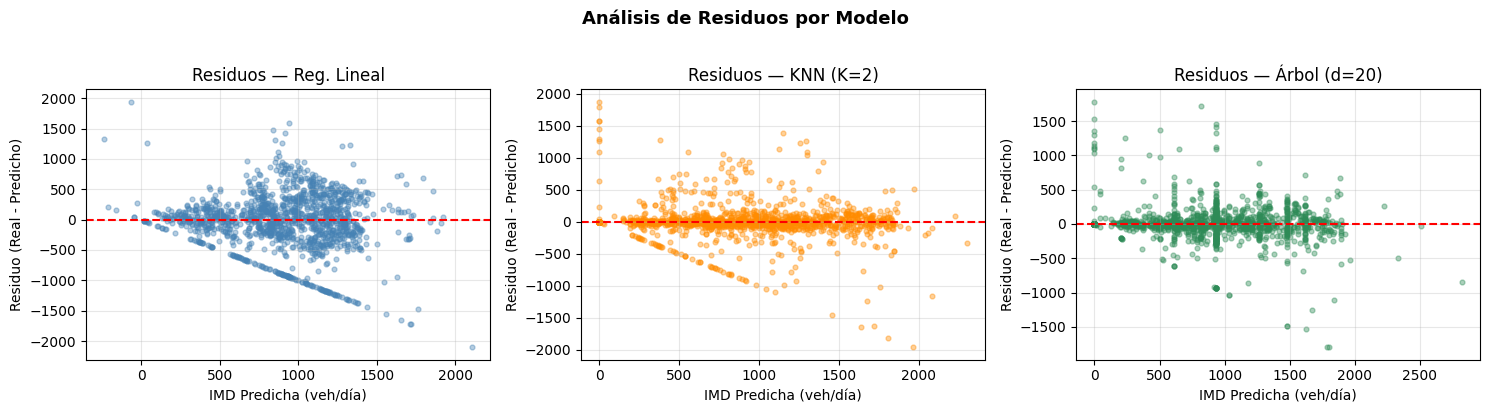

 Figura guardada: fig5_residuos.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (res_lr,   'Reg. Lineal',                'steelblue'),
    (res_knn,  f'KNN (K={mejor_k})',         'darkorange'),
    (res_tree, f'Árbol (d={mejor_depth})',   'seagreen'),
]

for ax, (res, nombre, color) in zip(axes, configs):
    residuos = y_test.values - res['y_pred']
    ax.scatter(res['y_pred'], residuos, alpha=0.4, color=color, s=12)
    ax.axhline(0, color='red', linestyle='--', lw=1.5)
    ax.set_xlabel('IMD Predicha (veh/día)')
    ax.set_ylabel('Residuo (Real - Predicho)')
    ax.set_title(f'Residuos — {nombre}')
    ax.grid(alpha=0.3)

plt.suptitle('Análisis de Residuos por Modelo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_residuos.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig5_residuos.png")

##  Importancia de variables (Árbol)
El árbol toma decisiones tipo: "si el año es mayor a 2019 AND el peaje es San Lorenzo → IMD ≈ 1,200". Cada vez que usa una variable para hacer un corte, reduce el error de predicción. La importancia mide cuánto redujo el error cada variable en total a lo largo de todo el árbol.

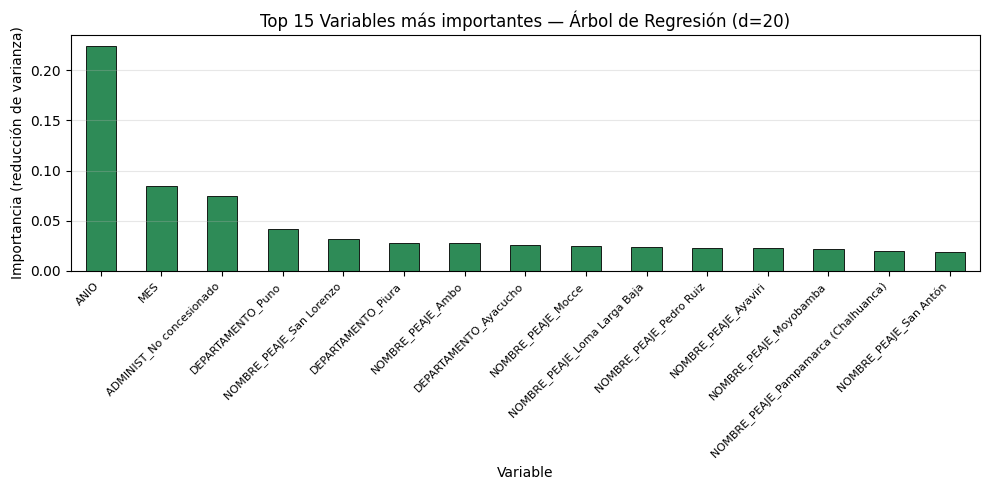

 Figura guardada: fig6_importancia_variables.png

Top 5 variables más importantes:
ANIO                        0.224125
MES                         0.085138
ADMINIST_No concesionado    0.074917
DEPARTAMENTO_Puno           0.042106
NOMBRE_PEAJE_San Lorenzo    0.032261


In [ ]:
importancias = pd.Series(tree_model.feature_importances_,
                          index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importancias.head(15).plot(kind='bar', color='seagreen', edgecolor='black', lw=0.6)
plt.title(f'Top 15 Variables más importantes — Árbol de Regresión (d={mejor_depth})')
plt.ylabel('Importancia (reducción de varianza)')
plt.xlabel('Variable')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figura guardada: fig6_importancia_variables.png")
print(f"\nTop 5 variables más importantes:")
print(importancias.head(5).to_string())

Qué significa eso:

ANIO es la variable más importante → tiene sentido, el flujo vehicular ha crecido año a año en el Perú


MES importa → hay estacionalidad (más tráfico en verano, feriados, etc.)


Algunos peajes y departamentos específicos tienen patrones muy distintos al resto

##  Resumen final

In [ ]:
mejor_modelo = resultados['R² Test'].idxmax()
print("\n" + "="*60)
print("  RESUMEN FINAL")
print("="*60)
print(f"\n   Mejor modelo por R²: {mejor_modelo}")
print(f"\n  Métricas del ganador:")
print(resultados.loc[mejor_modelo].to_string())
print(f"\n  Figuras generadas:")
figuras = [
    'fig0_distribucion_imd.png    → Distribución del IMD tras limpieza',
    'fig1_regresion_lineal.png    → Real vs Predicho (Regresión Lineal)',
    'fig2a_knn_seleccion_k.png   → Selección de K óptimo',
    'fig2b_knn_real_vs_pred.png  → Real vs Predicho (KNN)',
    'fig3a_arbol_seleccion_depth.png → Selección de profundidad óptima',
    'fig3b_arbol_real_vs_pred.png    → Real vs Predicho (Árbol)',
    'fig3c_arbol_visualizacion.png   → Visualización del árbol',
    'fig4_comparacion_modelos.png    → Comparación R², RMSE, MAE',
    'fig5_residuos.png               → Análisis de residuos',
    'fig6_importancia_variables.png  → Top 15 variables importantes',
]
for f in figuras:
    print(f"     {f}")

print("\n Código ejecutado exitosamente. Todas las figuras fueron guardadas.")
print("   Puedes descargarlas desde el panel de archivos de Colab (izquierda).")

print("Filas originales:", len(df_raw))
print("Filas finales:", len(df))
print("Columnas finales X:", X.shape[1])
print("Mejor K:", mejor_k)
print("Mejor profundidad:", mejor_depth)
print(resultados)
print(importancias.head(10))


print("="*70)
print("RESUMEN PARA INFORME")
print("="*70)

print("\nDATOS DEL DATASET")
print("Filas originales:", len(df_raw))
print("Filas finales tras limpieza:", len(df))
print("Variables finales de entrada:", X.shape[1])
print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])
print(f"Rango IMD: {y.min():.2f} - {y.max():.2f} veh/día")

print("\nHIPERPARÁMETROS SELECCIONADOS")
print("Mejor K:", mejor_k)
print("Mejor profundidad:", mejor_depth)

print("\nTABLA COMPARATIVA DE MODELOS")
print(resultados.to_string())

print("\nTOP 10 VARIABLES IMPORTANTES")
print(importancias.head(10).to_string())


  RESUMEN FINAL

   Mejor modelo por R²: Árbol de Regresión (profundidad óptima)

  Métricas del ganador:
R² Test              0.7603
RMSE Test          269.0500
MAE Test           140.6600
R² CV-5 (media)      0.7245
R² CV-5 (std)        0.0148

  Figuras generadas:
     fig0_distribucion_imd.png    → Distribución del IMD tras limpieza
     fig1_regresion_lineal.png    → Real vs Predicho (Regresión Lineal)
     fig2a_knn_seleccion_k.png   → Selección de K óptimo
     fig2b_knn_real_vs_pred.png  → Real vs Predicho (KNN)
     fig3a_arbol_seleccion_depth.png → Selección de profundidad óptima
     fig3b_arbol_real_vs_pred.png    → Real vs Predicho (Árbol)
     fig3c_arbol_visualizacion.png   → Visualización del árbol
     fig4_comparacion_modelos.png    → Comparación R², RMSE, MAE
     fig5_residuos.png               → Análisis de residuos
     fig6_importancia_variables.png  → Top 15 variables importantes

 Código ejecutado exitosamente. Todas las figuras fueron guardadas.
   Puedes des

## Conclusión Final

El análisis y modelado del flujo vehicular en peajes del Perú ha revelado que el **Árbol de Regresión** es el modelo con mejor rendimiento, obteniendo un R² de 0.7603 en el conjunto de prueba y un RMSE de 269.05 veh/día. Esto indica que el modelo explica una gran parte de la variabilidad en el flujo vehicular y realiza predicciones con un error absoluto medio de aproximadamente 140.66 vehículos por día.

Las variables más influyentes en el modelo son el **Año**, el **Mes**, el tipo de **Administración** (concesionado/no concesionado) y el **Departamento**. Esto sugiere que la tendencia temporal y la estacionalidad son factores clave, junto con particularidades de la gestión y ubicación de los peajes.